# GNN spatial pur pour la prédiction des injections `g` des 4 wells

Ce notebook construit un pipeline **complet** PyTorch / PyTorch Geometric pour prédire les injections `g` des 4 wells sur les **24 prochaines heures** à partir des **72 dernières heures** et de la **structure du réseau de gaz**.

## Principes imposés et respectés ici

- **Aucune utilisation de `q`**
- **Aucune feature dynamique d’arête**
- **Features d’arête = uniquement des attributs statiques du réseau**
- **Modèle purement spatial**
  - encodeur = **MLP**
  - message passing = **spatial uniquement**
  - décodeur = **MLP**
  - **pas de GRU, pas de LSTM, pas d’attention temporelle**
- L’information temporelle est injectée **uniquement** en empilant les **72h passées dans les features nodales d’entrée**
- Tous les **hyperparamètres** et **chemins** sont regroupés au début du notebook
- Le code est volontairement **très commenté**, avec beaucoup d’**assertions**, d’**affichages de shapes** et de **diagnostics**

In [45]:
# ============================================================
# Cellule 1 - Installation / vérification de PyTorch Geometric
# ============================================================
# Cette cellule est volontairement laissée commentée.
# Décommente-la si torch_geometric n'est pas installé dans ton environnement.
#
# Remarque :
# L'installation de PyG dépend de la version de torch et de CUDA.
# Vérifie d'abord :
#   python -c "import torch; print(torch.__version__, torch.version.cuda)"
#
# Puis adapte les commandes ci-dessous si nécessaire.
#
# Exemple classique pour torch 2.1.x + cu118 :
# !pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.1.0+cu118.html
# !pip install torch_geometric
#
# Exemple CPU :
# !pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.1.0+cpu.html
# !pip install torch_geometric

In [114]:
# ============================================================
# Cellule 2 - Hyperparamètres / constantes / chemins
# ============================================================
from pathlib import Path

CONFIG = {
    "SEED": 42,
    "HIST_HOURS": 72,
    "HORIZON_HOURS": 24,
    "STRIDE_HOURS": 24,
    "NUM_NODES": 28,
    "WELL_IDX": [0, 4, 16, 17],
    "USE_BIDIRECTIONAL_EDGES": True,
    "USE_PR_HISTORY": True,
    "USE_RES_DEMAND_HISTORY": True,
    "USE_IND_DEMAND_HISTORY": True,
    "USE_EXP_DEMAND_HISTORY": True,
    "USE_G_HISTORY": True,
    "USE_P_HISTORY": False,
    "USE_NODE_STATIC_IS_WELL": True,
    "USE_NODE_STATIC_SHARES": True,
    "USE_NODE_STATIC_PRESSURE_BOUNDS": True,
    "USE_NODE_STATIC_DEGREE": True,
    "EDGE_STATIC_COLUMNS": [
        "Natural gas flow constant [MNm3/(bar*h)2]",
        "Compressor factor",
        "High Linepack",
        "Initial linepack [MNm3]",
        "Linepack constant [MNm3/bar]",
        "Estimated lenght [km]",
    ],
    "TRAIN_END": "2024-10-01 00:00:00",
    "VAL_END":   "2024-11-01 00:00:00",
    "MODEL_TYPE": "nnconv",
    "HIDDEN_DIM": 128,
    "ENCODER_HIDDEN_DIMS": [256, 256],
    "DECODER_HIDDEN_DIMS": [256, 256],
    "NUM_MP_LAYERS": 3,
    "DROPOUT": 0.001,
    "USE_BATCHNORM": True,
    "RESIDUAL": True,
    "BATCH_SIZE": 64,
    "EPOCHS": 300,
    "LR": 5e-4,
    "WEIGHT_DECAY": 1e-5,
    "SCHEDULER_FACTOR": 0.7,
    "SCHEDULER_PATIENCE": 5,
    "SCHEDULER_MIN_LR": 1e-6,
    "EARLY_STOPPING_PATIENCE": 15,
    "GRAD_CLIP_NORM": 5.0,
    "PERSISTENCE_MODE": "last_24h",
    "NUM_PLOT_SAMPLES": 3,
    "PLOT_WELL_LOCAL_INDEX": 0,
}

CANDIDATE_BASE_DIRS = [Path(""), Path("/mnt/data")]
REQUIRED_FILES = {
    "network": "./Gas Network Data.xlsx",
    "cons_distrib": "./input/Gas Cons Distrib.xlsx",
    "cons_export": "./input/Gas Cons Export.xlsx",
    "cons_ind": "./input/Gas Cons Ind.xlsx",
    "decision": "./output/Decision_variablesRU.xlsx",
}

def resolve_file(filename: str) -> Path:
    for base in CANDIDATE_BASE_DIRS:
        candidate = base / filename
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f"Impossible de trouver le fichier: {filename}")

PATHS = {k: resolve_file(v) for k, v in REQUIRED_FILES.items()}

print("Fichiers détectés :")
for k, v in PATHS.items():
    print(f"  - {k:>12s} -> {v}")

Fichiers détectés :
  -      network -> C:\Users\yoans\TFE - GAZ\Gas Network Data.xlsx
  - cons_distrib -> C:\Users\yoans\TFE - GAZ\input\Gas Cons Distrib.xlsx
  -  cons_export -> C:\Users\yoans\TFE - GAZ\input\Gas Cons Export.xlsx
  -     cons_ind -> C:\Users\yoans\TFE - GAZ\input\Gas Cons Ind.xlsx
  -     decision -> C:\Users\yoans\TFE - GAZ\output\Decision_variablesRU.xlsx


In [115]:
# ============================================================
# Cellule 3 - Imports, seed, utilitaires de base
# ============================================================
import os
import random
import warnings
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import torch_geometric
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import NNConv, GINEConv
except Exception as e:
    raise ImportError(
        "torch_geometric n'est pas installé. Décommente d'abord la cellule d'installation."
    ) from e

warnings.filterwarnings("ignore", category=FutureWarning)

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CONFIG["SEED"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch version         :", torch.__version__)
print("torch_geometric       :", torch_geometric.__version__)
print("device                :", DEVICE)

def month_list_2024():
    return [f"{m:02d}" for m in range(1, 13)]

MONTHS = month_list_2024()

def pretty_shape(name, x):
    if hasattr(x, "shape"):
        print(f"{name:<35s} -> {tuple(x.shape)}")
    else:
        print(f"{name:<35s} -> type={type(x)}")

torch version         : 2.5.1
torch_geometric       : 2.7.0
device                : cuda


In [116]:
# ============================================================
# Cellule 4 - Exploration des fichiers et des feuilles Excel
# ============================================================
def show_excel_overview(path: Path):
    xls = pd.ExcelFile(path)
    print("=" * 90)
    print(path.name)
    print("Sheets:", xls.sheet_names)
    for sheet in xls.sheet_names[:8]:
        df = pd.read_excel(path, sheet_name=sheet, nrows=3)
        print(f"\n[{sheet}] shape preview = {df.shape}")
        print(df.head(2))

for p in PATHS.values():
    show_excel_overview(p)

Gas Network Data.xlsx
Sheets: ['Nodes', 'Pipelines', 'Check', 'Well', 'GasWellMap', 'GFPPMap', 'KI', 'KO']

[Nodes] shape preview = (3, 6)
   Gas Node  Res_Load_share_%  Ind_Load_share_%  Exp_Load_share_%  \
0         1          0.000000          0.000000                 0   
1         2          0.055556          0.105263                 0   

   Pr_min [bar]  Pr_max [bar]  
0            60            80  
1            60            80  

[Pipelines] shape preview = (3, 10)
   Pipeline  From node  To node  Natural gas flow constant [MNm3/(bar*h)2]  \
0         1          1        2                                    0.14400   
1         2          2        3                                    0.00739   

   Compressor factor  High Linepack  Initial linepack [MNm3]  \
0                  1              1                12.144166   
1                  1              1                10.592369   

   Linepack constant [MNm3/bar]  Estimated lenght [km]  \
0                         0.168   


[05-2024] shape preview = (3, 7)
            Date Time  Physical Flow VIP BENE (kWh)  \
0 2024-05-01 00:00:00                  1.083108e+07   
1 2024-05-01 01:00:00                  1.021360e+07   

   Physical Flow Blaregnies L (kWh)  Physical Flow Bras-Petange (kWh)  \
0                       1238965.047                        490944.006   
1                       1240518.867                        491778.415   

   Physical Flow VIP THE-ZPT (kWh)  GCV (kwh/Nm3)  Physical Flow (MNm3)  
0                     1.361298e+07      11.665682              2.243672  
1                     1.376698e+07      11.668447              2.203625  

[06-2024] shape preview = (3, 7)
            Date Time  Physical Flow VIP BENE (kWh)  \
0 2024-06-01 00:00:00                  1.010028e+07   
1 2024-06-01 01:00:00                  9.952075e+06   

   Physical Flow Blaregnies L (kWh)  Physical Flow Bras-Petange (kWh)  \
0                       1056974.585                        556644.448   
1           


[Time-01-2024] shape preview = (3, 2)
   Unnamed: 0             0
0           0   7370.565156
1           0  11222.879449

[q-02-2024] shape preview = (3, 34)
   Unnamed: 0         0         1         2         3         4         5  \
0           0  2.135997  0.079173  0.888889  1.120665  0.000000  1.398563   
1           1  2.142751  0.136875  0.025496  1.777778  0.003787  1.238461   

          6         7         8  ...        23        24        25        26  \
0  0.444444  0.668141  0.920204  ...  0.650085  0.081186  0.511128  1.426165   
1  0.444444  1.353063  0.866072  ...  1.052778  0.110504  0.802475  1.443289   

         27        28        29        30        31        32  
0  0.039381  0.316843  1.140996  0.122243  0.242913  0.069600  
1  0.039128  0.508049  1.173227  0.123710  0.242771  0.074839  

[2 rows x 34 columns]

[pr-02-2024] shape preview = (3, 29)
   Unnamed: 0          0          1          2          3          4  \
0           0  71.729656  71.508821  71.47

In [117]:
# ============================================================
# Cellule 5 - Lecture des données statiques du réseau
# ============================================================
nodes_df = pd.read_excel(PATHS["network"], sheet_name="Nodes")
pipes_df = pd.read_excel(PATHS["network"], sheet_name="Pipelines")
well_df = pd.read_excel(PATHS["network"], sheet_name="Well")
gaswell_map_df = pd.read_excel(PATHS["network"], sheet_name="GasWellMap")
gfpp_map_df = pd.read_excel(PATHS["network"], sheet_name="GFPPMap")
ki_df = pd.read_excel(PATHS["network"], sheet_name="KI")
ko_df = pd.read_excel(PATHS["network"], sheet_name="KO")

pretty_shape("nodes_df", nodes_df)
pretty_shape("pipes_df", pipes_df)
pretty_shape("well_df", well_df)
pretty_shape("gaswell_map_df", gaswell_map_df)
pretty_shape("gfpp_map_df", gfpp_map_df)
pretty_shape("ki_df", ki_df)
pretty_shape("ko_df", ko_df)

assert len(nodes_df) == CONFIG["NUM_NODES"], "Le nombre de noeuds attendu est 28."
assert len(CONFIG["WELL_IDX"]) == 4, "On attend 4 wells."
assert pipes_df["From node"].min() >= 1 and pipes_df["To node"].min() >= 1

display(nodes_df.head())
display(pipes_df.head())
display(well_df)

nodes_df                            -> (28, 6)
pipes_df                            -> (33, 10)
well_df                             -> (4, 10)
gaswell_map_df                      -> (28, 4)
gfpp_map_df                         -> (28, 24)
ki_df                               -> (9, 12)
ko_df                               -> (26, 12)


,Gas Node,Res_Load_share_%,Ind_Load_share_%,Exp_Load_share_%,Pr_min [bar],Pr_max [bar]
0,1,0.000000,0.000000,0.0,60,80
1,2,0.055556,0.105263,0.0,60,80
2,3,0.055556,0.052632,0.0,60,80
3,4,0.055556,0.052632,0.0,60,80
4,5,0.000000,0.000000,0.0,60,80


,Pipeline,From node,To node,Natural gas flow constant [MNm3/(bar*h)2],Compressor factor,High Linepack,Initial linepack [MNm3],Linepack constant [MNm3/bar],Estimated lenght [km],Linepack constant quantifies
0,1,1,2,0.14400,1.0,1,12.144166,0.1680,25.0,how much gas volume is
1,2,2,3,0.00739,1.0,1,10.592369,0.1470,30.0,added or removed from the
2,3,2,4,0.08270,1.0,1,2.515726,0.0349,35.0,pipeline for each change in pressure
3,4,2,6,0.08270,1.0,1,2.516711,0.0349,30.0,NaN
4,5,3,27,0.07670,1.0,0,0.000000,0.0142,65.0,NaN


,Gas node,Gmax [MNm3/h],Day-ahead offer price [€/MNm3],Spot Market TTF Q4 2024 :,Unnamed: 4,Unnamed: 5,GCV moyen décembre :,Unnamed: 7,Unnamed: 8,OLD Day-ahead offer price (€/Mm3)
0,1,4.0,497394,43.251667,€/MWh,NaN,11.5,kWh/Nm3,NaN,65717.14
1,5,2.5,497394,0.043252,€/kWh,NaN,NaN,NaN,NaN,78860.57
2,17,2.2,497394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18,1.5,497394,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [118]:
# ============================================================
# Cellule 6 - Helpers de lecture des séries 2024
# ============================================================
def drop_unnamed_first_col(df: pd.DataFrame) -> pd.DataFrame:
    if len(df.columns) > 0 and str(df.columns[0]).startswith("Unnamed"):
        df = df.drop(columns=[df.columns[0]])
    return df

def read_simple_monthly_series(path: Path, months, value_col: str) -> pd.DataFrame:
    all_parts = []
    for m in months:
        sheet = f"{m}-2024"
        df = pd.read_excel(path, sheet_name=sheet)
        df = df[["Date Time", value_col]].copy()
        df["Date Time"] = pd.to_datetime(df["Date Time"])
        df = df.rename(columns={value_col: "value"})
        df["month"] = m
        all_parts.append(df)
    out = pd.concat(all_parts, axis=0, ignore_index=True)
    out = out.sort_values("Date Time").reset_index(drop=True)
    return out

def read_decision_tensor(prefix: str, months, decision_path: Path):
    all_values = []
    all_times = []
    for m in months:
        sheet = f"{prefix}-{m}-2024"
        df = pd.read_excel(decision_path, sheet_name=sheet)
        df = drop_unnamed_first_col(df)
        arr = df.to_numpy(dtype=float)
        start_ts = pd.Timestamp(f"2024-{m}-01 00:00:00")
        idx = pd.date_range(start=start_ts, periods=len(df), freq="h")
        all_values.append(arr)
        all_times.append(idx)
    values = np.vstack(all_values)
    times = pd.DatetimeIndex(np.concatenate([x.to_numpy() for x in all_times]))
    return values, times

In [119]:
# ============================================================
# Cellule 7 - Lecture et concaténation mensuelle des séries 2024
# ============================================================
cons_distrib_df = read_simple_monthly_series(PATHS["cons_distrib"], MONTHS, "Physical Flow (MNm3)")
cons_ind_df     = read_simple_monthly_series(PATHS["cons_ind"], MONTHS, "Physical Flow (MNm3)")
cons_export_df  = read_simple_monthly_series(PATHS["cons_export"], MONTHS, "Physical Flow (MNm3)")

g_full,  ts_g  = read_decision_tensor("g",  MONTHS, PATHS["decision"])
pr_full, ts_pr = read_decision_tensor("pr", MONTHS, PATHS["decision"])
q_full,  ts_q  = read_decision_tensor("q",  MONTHS, PATHS["decision"])
p_full,  ts_p  = read_decision_tensor("p",  MONTHS, PATHS["decision"])

assert len(cons_distrib_df) == len(cons_ind_df) == len(cons_export_df)
assert len(ts_g) == len(ts_pr) == len(ts_q) == len(ts_p) == len(cons_distrib_df)
assert (ts_g == ts_pr).all()
assert (ts_g == ts_q).all()
assert (ts_g == ts_p).all()
assert (ts_g == pd.DatetimeIndex(cons_distrib_df["Date Time"])).all()
assert (ts_g == pd.DatetimeIndex(cons_ind_df["Date Time"])).all()
assert (ts_g == pd.DatetimeIndex(cons_export_df["Date Time"])).all()

pretty_shape("g_full", g_full)
pretty_shape("pr_full", pr_full)
pretty_shape("q_full", q_full)
pretty_shape("p_full", p_full)
pretty_shape("cons_distrib_df", cons_distrib_df)
pretty_shape("cons_ind_df", cons_ind_df)
pretty_shape("cons_export_df", cons_export_df)

assert g_full.shape[1] == 4
assert pr_full.shape[1] == CONFIG["NUM_NODES"]

print("Plage temporelle globale :", ts_g.min(), "->", ts_g.max())
display(cons_distrib_df.head())
display(cons_ind_df.head())
display(cons_export_df.head())

g_full                              -> (8784, 4)
pr_full                             -> (8784, 28)
q_full                              -> (8784, 33)
p_full                              -> (8784, 24)
cons_distrib_df                     -> (8784, 3)
cons_ind_df                         -> (8784, 3)
cons_export_df                      -> (8784, 3)
Plage temporelle globale : 2024-01-01 00:00:00 -> 2024-12-31 23:00:00


,Date Time,value,month
0,2024-01-01 00:00:00,0.613663,01
1,2024-01-01 01:00:00,0.602864,01
2,2024-01-01 02:00:00,0.600239,01
3,2024-01-01 03:00:00,0.604978,01
4,2024-01-01 04:00:00,0.652098,01


,Date Time,value,month
0,2024-01-01 00:00:00,0.338141,01
1,2024-01-01 01:00:00,0.342184,01
2,2024-01-01 02:00:00,0.341420,01
3,2024-01-01 03:00:00,0.343037,01
4,2024-01-01 04:00:00,0.343228,01


,Date Time,value,month
0,2024-01-01 00:00:00,2.226069,01
1,2024-01-01 01:00:00,2.226069,01
2,2024-01-01 02:00:00,2.226069,01
3,2024-01-01 03:00:00,2.226069,01
4,2024-01-01 04:00:00,2.226069,01


In [120]:
# ============================================================
# Cellule 8 - Construction des features nodales dynamiques
# ============================================================
num_nodes = CONFIG["NUM_NODES"]
well_idx = CONFIG["WELL_IDX"]

res_share = nodes_df["Res_Load_share_%"].to_numpy(dtype=float)
ind_share = nodes_df["Ind_Load_share_%"].to_numpy(dtype=float)
exp_share = nodes_df["Exp_Load_share_%"].to_numpy(dtype=float)

print("Sommes des parts de charge :")
print("  Res =", res_share.sum())
print("  Ind =", ind_share.sum())
print("  Exp =", exp_share.sum())

assert np.all(res_share >= 0), "Res_Load_share_% contient des valeurs négatives"
assert np.all(ind_share >= 0), "Ind_Load_share_% contient des valeurs négatives"
assert np.all(exp_share >= 0), "Exp_Load_share_% contient des valeurs négatives"

res_total = cons_distrib_df["value"].to_numpy(dtype=float)
ind_total = cons_ind_df["value"].to_numpy(dtype=float)
exp_total = cons_export_df["value"].to_numpy(dtype=float)

res_nodal = res_total[:, None] * res_share[None, :]
ind_nodal = ind_total[:, None] * ind_share[None, :]
exp_nodal = exp_total[:, None] * exp_share[None, :]

g_nodal = np.zeros((len(ts_g), num_nodes), dtype=float)
g_nodal[:, well_idx] = g_full

p_nodal = np.zeros((len(ts_g), num_nodes), dtype=float)

dyn_feature_dict = {}
if CONFIG["USE_PR_HISTORY"]:
    dyn_feature_dict["pr"] = pr_full
if CONFIG["USE_RES_DEMAND_HISTORY"]:
    dyn_feature_dict["res_demand"] = res_nodal
if CONFIG["USE_IND_DEMAND_HISTORY"]:
    dyn_feature_dict["ind_demand"] = ind_nodal
if CONFIG["USE_EXP_DEMAND_HISTORY"]:
    dyn_feature_dict["exp_demand"] = exp_nodal
if CONFIG["USE_G_HISTORY"]:
    dyn_feature_dict["g_history"] = g_nodal
if CONFIG["USE_P_HISTORY"]:
    dyn_feature_dict["p_history"] = p_nodal

dyn_feature_names = list(dyn_feature_dict.keys())
assert len(dyn_feature_names) > 0

dyn_tensor = np.stack([dyn_feature_dict[name] for name in dyn_feature_names], axis=-1)

pretty_shape("dyn_tensor [T, N, F_dyn]", dyn_tensor)
print("dyn_feature_names =", dyn_feature_names)

assert dyn_tensor.shape[0] == len(ts_g)
assert dyn_tensor.shape[1] == num_nodes
assert dyn_tensor.shape[2] == len(dyn_feature_names)

print("Exemple dyn_tensor[0, :5, :]:")
print(dyn_tensor[0, :5, :])

Sommes des parts de charge :
  Res = 1.0277777777777777
  Ind = 0.9999999999999999
  Exp = 1.0
dyn_tensor [T, N, F_dyn]            -> (8784, 28, 5)
dyn_feature_names = ['pr', 'res_demand', 'ind_demand', 'exp_demand', 'g_history']
Exemple dyn_tensor[0, :5, :]:
[[7.13555086e+01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  2.16343681e+00]
 [7.11111111e+01 3.40923773e-02 3.55937863e-02 0.00000000e+00
  0.00000000e+00]
 [7.10807684e+01 3.40923773e-02 1.77968931e-02 0.00000000e+00
  0.00000000e+00]
 [7.11104593e+01 3.40923773e-02 1.77968931e-02 0.00000000e+00
  0.00000000e+00]
 [7.06928678e+01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  3.44229233e-01]]


In [121]:
# ============================================================
# Cellule 9 - Construction des features nodales statiques
# ============================================================
degrees = np.zeros(num_nodes, dtype=float)
for _, row in pipes_df.iterrows():
    u = int(row["From node"]) - 1
    v = int(row["To node"]) - 1
    degrees[u] += 1
    degrees[v] += 1

node_static_parts = []
node_static_names = []

if CONFIG["USE_NODE_STATIC_IS_WELL"]:
    is_well = np.zeros(num_nodes, dtype=float)
    is_well[well_idx] = 1.0
    node_static_parts.append(is_well[:, None])
    node_static_names.append("is_well")

if CONFIG["USE_NODE_STATIC_SHARES"]:
    node_static_parts.extend([
        res_share[:, None],
        ind_share[:, None],
        exp_share[:, None],
    ])
    node_static_names.extend(["res_share", "ind_share", "exp_share"])

if CONFIG["USE_NODE_STATIC_PRESSURE_BOUNDS"]:
    pr_min = nodes_df["Pr_min [bar]"].to_numpy(dtype=float)
    pr_max = nodes_df["Pr_max [bar]"].to_numpy(dtype=float)
    node_static_parts.extend([pr_min[:, None], pr_max[:, None]])
    node_static_names.extend(["pr_min", "pr_max"])

if CONFIG["USE_NODE_STATIC_DEGREE"]:
    node_static_parts.append(degrees[:, None])
    node_static_names.append("degree")

node_static = np.concatenate(node_static_parts, axis=1) if len(node_static_parts) > 0 else np.zeros((num_nodes, 0))

pretty_shape("node_static [N, F_static]", node_static)
print("node_static_names =", node_static_names)
assert node_static.shape[0] == num_nodes

node_static [N, F_static]           -> (28, 7)
node_static_names = ['is_well', 'res_share', 'ind_share', 'exp_share', 'pr_min', 'pr_max', 'degree']


In [122]:
# ============================================================
# Cellule 10 - Construction de edge_index et des features d'arête statiques
# ============================================================
edge_static_cols = CONFIG["EDGE_STATIC_COLUMNS"]
for col in edge_static_cols:
    assert col in pipes_df.columns, f"Colonne edge statique introuvable: {col}"

edge_static_base = pipes_df[edge_static_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=float)
pretty_shape("edge_static_base [E_raw, F_edge]", edge_static_base)

edge_pairs = []
edge_attrs = []

for i, row in pipes_df.iterrows():
    u = int(row["From node"]) - 1
    v = int(row["To node"]) - 1
    ea = edge_static_base[i]
    edge_pairs.append((u, v))
    edge_attrs.append(ea)
    if CONFIG["USE_BIDIRECTIONAL_EDGES"]:
        edge_pairs.append((v, u))
        edge_attrs.append(ea.copy())

edge_index = torch.tensor(np.array(edge_pairs, dtype=np.int64).T, dtype=torch.long)
edge_attr_raw = np.array(edge_attrs, dtype=float)

pretty_shape("edge_index", edge_index)
pretty_shape("edge_attr_raw [E, F_edge]", edge_attr_raw)

assert edge_index.shape[0] == 2
assert edge_attr_raw.shape[0] == edge_index.shape[1]
assert edge_attr_raw.shape[1] == len(edge_static_cols)

edge_static_base [E_raw, F_edge]    -> (33, 6)
edge_index                          -> (2, 66)
edge_attr_raw [E, F_edge]           -> (66, 6)


In [123]:
# ============================================================
# Cellule 11 - Split train / val / test + normalisation
# ============================================================
TRAIN_END = pd.Timestamp(CONFIG["TRAIN_END"])
VAL_END   = pd.Timestamp(CONFIG["VAL_END"])

HIST = CONFIG["HIST_HOURS"]
HOR  = CONFIG["HORIZON_HOURS"]
STR  = CONFIG["STRIDE_HOURS"]

all_start_indices = np.arange(0, len(ts_g) - HIST - HOR + 1, STR, dtype=int)
target_start_times = ts_g[all_start_indices + HIST]

train_window_mask = target_start_times < TRAIN_END
val_window_mask   = (target_start_times >= TRAIN_END) & (target_start_times < VAL_END)
test_window_mask  = target_start_times >= VAL_END

print("Nombre total de fenêtres :", len(all_start_indices))
print("Train windows            :", int(train_window_mask.sum()))
print("Val windows              :", int(val_window_mask.sum()))
print("Test windows             :", int(test_window_mask.sum()))

assert train_window_mask.sum() > 0
assert val_window_mask.sum() > 0
assert test_window_mask.sum() > 0

hour_train_mask = ts_g < TRAIN_END

dyn_scaler = StandardScaler()
dyn_scaler.fit(dyn_tensor[hour_train_mask].reshape(-1, dyn_tensor.shape[-1]))

node_static_scaler = StandardScaler()
if node_static.shape[1] > 0:
    node_static_scaler.fit(node_static)
else:
    node_static_scaler = None

edge_scaler = StandardScaler()
edge_scaler.fit(edge_attr_raw)

target_scaler = StandardScaler()
target_scaler.fit(g_full[hour_train_mask].reshape(-1, 1))

print("dyn_scaler mean shape    :", dyn_scaler.mean_.shape)
print("edge_scaler mean shape   :", edge_scaler.mean_.shape)
print("target_scaler mean/scale :", target_scaler.mean_, target_scaler.scale_)

dyn_tensor_scaled = dyn_scaler.transform(dyn_tensor.reshape(-1, dyn_tensor.shape[-1])).reshape(dyn_tensor.shape)
if node_static_scaler is not None:
    node_static_scaled = node_static_scaler.transform(node_static)
else:
    node_static_scaled = node_static.copy()

edge_attr_scaled = edge_scaler.transform(edge_attr_raw)
g_full_scaled = target_scaler.transform(g_full.reshape(-1, 1)).reshape(g_full.shape)

pretty_shape("dyn_tensor_scaled", dyn_tensor_scaled)
pretty_shape("node_static_scaled", node_static_scaled)
pretty_shape("edge_attr_scaled", edge_attr_scaled)
pretty_shape("g_full_scaled", g_full_scaled)

Nombre total de fenêtres : 363
Train windows            : 271
Val windows              : 31
Test windows             : 61
dyn_scaler mean shape    : (5,)
edge_scaler mean shape   : (6,)
target_scaler mean/scale : [1.21370289] [0.84398355]
dyn_tensor_scaled                   -> (8784, 28, 5)
node_static_scaled                  -> (28, 7)
edge_attr_scaled                    -> (66, 6)
g_full_scaled                       -> (8784, 4)


In [124]:
# ============================================================
# Cellule 12 - Fenêtres glissantes + diagnostic d'alignement
# ============================================================
def build_single_window(start_idx: int):
    hist_slice = slice(start_idx, start_idx + HIST)
    target_slice = slice(start_idx + HIST, start_idx + HIST + HOR)

    hist_dyn = dyn_tensor_scaled[hist_slice]
    hist_dyn = np.transpose(hist_dyn, (1, 0, 2))
    hist_dyn = hist_dyn.reshape(num_nodes, -1)

    x = np.concatenate([hist_dyn, node_static_scaled], axis=1)
    y = g_full_scaled[target_slice].T
    y_real = g_full[target_slice].T

    return {
        "x": x.astype(np.float32),
        "y": y.astype(np.float32),
        "y_real": y_real.astype(np.float32),
        "start_idx": np.int64(start_idx),
        "hist_start_idx": np.int64(start_idx),
        "hist_end_idx": np.int64(start_idx + HIST - 1),
        "target_start_idx": np.int64(start_idx + HIST),
        "target_end_idx": np.int64(start_idx + HIST + HOR - 1),
    }

sample0 = build_single_window(int(all_start_indices[0]))
pretty_shape("sample0['x']", sample0["x"])
pretty_shape("sample0['y']", sample0["y"])
pretty_shape("sample0['y_real']", sample0["y_real"])

expected_x_dim = HIST * dyn_tensor.shape[-1] + node_static_scaled.shape[1]
assert sample0["x"].shape == (num_nodes, expected_x_dim)
assert sample0["y"].shape == (len(well_idx), HOR)

def check_alignment_for_window(start_idx: int, verbose: bool = True):
    sample = build_single_window(start_idx)
    target_start_idx = int(sample["target_start_idx"])
    target_end_idx   = int(sample["target_end_idx"])
    expected = g_full[target_start_idx:target_end_idx + 1].T
    actual   = sample["y_real"]
    assert expected.shape == actual.shape
    assert np.allclose(expected, actual), "Problème d'alignement entre y_real et g_full[target_idx]."
    if verbose:
        print("Alignment OK")
        print("target_start_idx:", target_start_idx)
        print("target_end_idx  :", target_end_idx)
        print("target_start_ts :", ts_g[target_start_idx])
        print("target_end_ts   :", ts_g[target_end_idx])

for idx in [int(all_start_indices[0]), int(all_start_indices[10]), int(all_start_indices[-1])]:
    check_alignment_for_window(idx, verbose=True)

print("Tous les diagnostics d'alignement de base sont OK.")

sample0['x']                        -> (28, 367)
sample0['y']                        -> (4, 24)
sample0['y_real']                   -> (4, 24)
Alignment OK
target_start_idx: 72
target_end_idx  : 95
target_start_ts : 2024-01-04 00:00:00
target_end_ts   : 2024-01-04 23:00:00
Alignment OK
target_start_idx: 312
target_end_idx  : 335
target_start_ts : 2024-01-14 00:00:00
target_end_ts   : 2024-01-14 23:00:00
Alignment OK
target_start_idx: 8760
target_end_idx  : 8783
target_start_ts : 2024-12-31 00:00:00
target_end_ts   : 2024-12-31 23:00:00
Tous les diagnostics d'alignement de base sont OK.


In [125]:
# ============================================================
# Cellule 13 - Dataset PyG / DataLoader
# ============================================================
class GasSpatialWindowDataset(torch.utils.data.Dataset):
    def __init__(self, start_indices):
        self.start_indices = np.array(start_indices, dtype=int)

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, idx: int):
        start_idx = int(self.start_indices[idx])
        sample = build_single_window(start_idx)
        data = Data(
            x=torch.tensor(sample["x"], dtype=torch.float32),
            edge_index=edge_index.clone(),
            edge_attr=torch.tensor(edge_attr_scaled, dtype=torch.float32),
            y=torch.tensor(sample["y"], dtype=torch.float32),
            well_mask=torch.tensor(np.isin(np.arange(num_nodes), well_idx), dtype=torch.bool),
        )
        data.start_idx = int(sample["start_idx"])
        data.hist_start_idx = int(sample["hist_start_idx"])
        data.hist_end_idx = int(sample["hist_end_idx"])
        data.target_start_idx = int(sample["target_start_idx"])
        data.target_end_idx = int(sample["target_end_idx"])
        data.y_real = torch.tensor(sample["y_real"], dtype=torch.float32)
        return data

train_start_idx = all_start_indices[train_window_mask]
val_start_idx   = all_start_indices[val_window_mask]
test_start_idx  = all_start_indices[test_window_mask]

train_ds = GasSpatialWindowDataset(train_start_idx)
val_ds   = GasSpatialWindowDataset(val_start_idx)
test_ds  = GasSpatialWindowDataset(test_start_idx)

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

print("len(train_ds) =", len(train_ds))
print("len(val_ds)   =", len(val_ds))
print("len(test_ds)  =", len(test_ds))

batch = next(iter(train_loader))
print(batch)
pretty_shape("batch.x", batch.x)
pretty_shape("batch.edge_index", batch.edge_index)
pretty_shape("batch.edge_attr", batch.edge_attr)
pretty_shape("batch.y", batch.y)
pretty_shape("batch.well_mask", batch.well_mask)

assert batch.x.shape[1] == expected_x_dim
assert batch.edge_attr.shape[1] == edge_attr_scaled.shape[1]
assert batch.y.shape[-1] == HOR

len(train_ds) = 271
len(val_ds)   = 31
len(test_ds)  = 61
DataBatch(x=[1792, 367], edge_index=[2, 4224], edge_attr=[4224, 6], y=[256, 24], well_mask=[1792], start_idx=[64], hist_start_idx=[64], hist_end_idx=[64], target_start_idx=[64], target_end_idx=[64], y_real=[256, 24], batch=[1792], ptr=[65])
batch.x                             -> (1792, 367)
batch.edge_index                    -> (2, 4224)
batch.edge_attr                     -> (4224, 6)
batch.y                             -> (256, 24)
batch.well_mask                     -> (1792,)


In [126]:
# ============================================================
# Cellule 14 - Blocs MLP utilitaires
# ============================================================
class MLP(nn.Module):
    def __init__(self, dims, dropout: float = 0.0, use_batchnorm: bool = False, activate_last: bool = False):
        super().__init__()
        assert len(dims) >= 2
        layers = []
        for i in range(len(dims) - 1):
            in_dim = dims[i]
            out_dim = dims[i + 1]
            layers.append(nn.Linear(in_dim, out_dim))
            is_last = (i == len(dims) - 2)
            if (not is_last) or activate_last:
                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(out_dim))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [127]:
# ============================================================
# Cellule 15 - Modèle GNN purement spatial
# ============================================================
class SpatialGasGNN(nn.Module):
    def __init__(
        self,
        in_dim: int,
        edge_dim: int,
        hidden_dim: int,
        horizon: int,
        model_type: str = "nnconv",
        encoder_hidden_dims = [256, 128],
        decoder_hidden_dims = [128, 64],
        num_mp_layers: int = 3,
        dropout: float = 0.0,
        use_batchnorm: bool = True,
        residual: bool = True,
    ):
        super().__init__()
        self.model_type = model_type.lower()
        self.hidden_dim = hidden_dim
        self.horizon = horizon
        self.num_mp_layers = num_mp_layers
        self.residual = residual

        enc_dims = [in_dim] + list(encoder_hidden_dims) + [hidden_dim]
        self.encoder = MLP(enc_dims, dropout=dropout, use_batchnorm=use_batchnorm, activate_last=False)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_mp_layers):
            if self.model_type == "nnconv":
                edge_network = MLP(
                    [edge_dim, hidden_dim, hidden_dim * hidden_dim],
                    dropout=dropout,
                    use_batchnorm=False,
                    activate_last=False,
                )
                conv = NNConv(hidden_dim, hidden_dim, nn=edge_network, aggr="mean")
            elif self.model_type == "gine":
                nn_mlp = MLP(
                    [hidden_dim, hidden_dim, hidden_dim],
                    dropout=dropout,
                    use_batchnorm=False,
                    activate_last=False,
                )
                conv = GINEConv(nn=nn_mlp, edge_dim=edge_dim)
            else:
                raise ValueError(f"MODEL_TYPE inconnu: {model_type}")

            self.convs.append(conv)
            self.norms.append(nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity())

        dec_dims = [hidden_dim] + list(decoder_hidden_dims) + [horizon]
        self.decoder = MLP(dec_dims, dropout=dropout, use_batchnorm=use_batchnorm, activate_last=False)

    def forward(self, x, edge_index, edge_attr):
        h = self.encoder(x)
        for conv, norm in zip(self.convs, self.norms):
            h_in = h
            h = conv(h, edge_index, edge_attr)
            h = norm(h)
            h = F.relu(h)
            if self.residual:
                h = h + h_in
        out = self.decoder(h)
        return out

model = SpatialGasGNN(
    in_dim=expected_x_dim,
    edge_dim=edge_attr_scaled.shape[1],
    hidden_dim=CONFIG["HIDDEN_DIM"],
    horizon=HOR,
    model_type=CONFIG["MODEL_TYPE"],
    encoder_hidden_dims=CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims=CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers=CONFIG["NUM_MP_LAYERS"],
    dropout=CONFIG["DROPOUT"],
    use_batchnorm=CONFIG["USE_BATCHNORM"],
    residual=CONFIG["RESIDUAL"],
).to(DEVICE)

print(model)

batch = next(iter(train_loader)).to(DEVICE)
with torch.no_grad():
    pred = model(batch.x, batch.edge_index, batch.edge_attr)

pretty_shape("pred", pred)
assert pred.shape[0] == batch.x.shape[0]
assert pred.shape[1] == HOR

SpatialGasGNN(
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=367, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.001, inplace=False)
      (4): Linear(in_features=256, out_features=256, bias=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.001, inplace=False)
      (8): Linear(in_features=256, out_features=128, bias=True)
    )
  )
  (convs): ModuleList(
    (0-2): 3 x NNConv(128, 128, aggr=mean, nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=6, out_features=128, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.001, inplace=False)
        (3): Linear(in_features=128, out_features=16384, bias=True)
      )
    ))
  )
  (norms): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [128]:
# ============================================================
# Cellule 16 - Loss, métriques, inverse_transform, baseline
# ============================================================
def extract_well_predictions_from_batch(node_pred: torch.Tensor, batch) -> torch.Tensor:
    return node_pred[batch.well_mask]

def mse_loss_on_wells(node_pred: torch.Tensor, batch) -> torch.Tensor:
    well_pred = extract_well_predictions_from_batch(node_pred, batch)
    y_true = batch.y.view(-1, HOR)
    assert well_pred.shape == y_true.shape
    return F.mse_loss(well_pred, y_true)

def inverse_transform_targets(arr_scaled: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr_scaled)
    return target_scaler.inverse_transform(arr.reshape(-1, 1)).reshape(arr.shape)

def mae_rmse_nmae(y_true: np.ndarray, y_pred: np.ndarray):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.mean(np.abs(y_true)) + 1e-12
    nmae = mae / denom
    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae}

def per_horizon_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    rows = []
    for h in range(y_true.shape[-1]):
        m = mae_rmse_nmae(y_true[:, :, h], y_pred[:, :, h])
        rows.append({"h": h + 1, **m})
    return pd.DataFrame(rows)

def persistence_forecast_for_sample(start_idx: int, mode: str = "last_24h") -> np.ndarray:
    hist_g = g_full[start_idx:start_idx + HIST]
    if mode == "last_value":
        last_val = hist_g[-1]
        pred = np.repeat(last_val[:, None], HOR, axis=1)
    elif mode == "last_24h":
        pred = hist_g[-HOR:].T
    else:
        raise ValueError(f"PERSISTENCE_MODE inconnu: {mode}")
    assert pred.shape == (4, HOR)
    return pred

In [129]:
# ============================================================
# Cellule 17 - Boucles train / validation / early stopping
# ============================================================
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["LR"],
    weight_decay=CONFIG["WEIGHT_DECAY"],
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"],
    min_lr=CONFIG["SCHEDULER_MIN_LR"],
)

def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    losses = []
    for batch in loader:
        batch = batch.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            node_pred = model(batch.x, batch.edge_index, batch.edge_attr)
            loss = mse_loss_on_wells(node_pred, batch)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                if CONFIG["GRAD_CLIP_NORM"] is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["GRAD_CLIP_NORM"])
                optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

class EarlyStopping:
    def __init__(self, patience: int = 15):
        self.patience = patience
        self.best_loss = np.inf
        self.best_state = None
        self.num_bad_epochs = 0

    def step(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.num_bad_epochs = 0
            return False
        self.num_bad_epochs += 1
        return self.num_bad_epochs >= self.patience

early_stopper = EarlyStopping(patience=CONFIG["EARLY_STOPPING_PATIENCE"])

history = {"train_loss": [], "val_loss": [], "lr": []}

In [130]:
# ============================================================
# Cellule 18 - Entraînement
# ============================================================
for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_loss = run_one_epoch(model, val_loader, optimizer=None)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    if epoch == 1 or epoch % 1 == 0:
        print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | lr={current_lr:.2e}")

    should_stop = early_stopper.step(val_loss, model)
    if should_stop:
        print(f"Early stopping déclenché à l'epoch {epoch}.")
        break

assert early_stopper.best_state is not None, "Aucun meilleur état sauvegardé."
model.load_state_dict(early_stopper.best_state)
print("Meilleur val_loss:", early_stopper.best_loss)

Epoch 001 | train_loss=0.657458 | val_loss=0.580139 | lr=5.00e-04
Epoch 002 | train_loss=0.210072 | val_loss=0.394427 | lr=5.00e-04
Epoch 003 | train_loss=0.186888 | val_loss=0.285344 | lr=5.00e-04
Epoch 004 | train_loss=0.179599 | val_loss=0.242009 | lr=5.00e-04
Epoch 005 | train_loss=0.168495 | val_loss=0.180595 | lr=5.00e-04
Epoch 006 | train_loss=0.167443 | val_loss=0.166503 | lr=5.00e-04
Epoch 007 | train_loss=0.159849 | val_loss=0.179061 | lr=5.00e-04
Epoch 008 | train_loss=0.160914 | val_loss=0.162701 | lr=5.00e-04
Epoch 009 | train_loss=0.166359 | val_loss=0.150502 | lr=5.00e-04
Epoch 010 | train_loss=0.151491 | val_loss=0.151888 | lr=5.00e-04
Epoch 011 | train_loss=0.154146 | val_loss=0.151929 | lr=5.00e-04
Epoch 012 | train_loss=0.148636 | val_loss=0.149302 | lr=5.00e-04
Epoch 013 | train_loss=0.146091 | val_loss=0.147113 | lr=5.00e-04
Epoch 014 | train_loss=0.147826 | val_loss=0.149722 | lr=5.00e-04
Epoch 015 | train_loss=0.142535 | val_loss=0.154115 | lr=5.00e-04
Epoch 016 

In [131]:
# ============================================================
# Cellule 19 - Inference helpers
# ============================================================
@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()

    preds_scaled = []
    trues_scaled = []
    trues_real = []
    metas = []

    for batch in loader:
        batch = batch.to(DEVICE)
        node_pred = model(batch.x, batch.edge_index, batch.edge_attr)
        well_pred = extract_well_predictions_from_batch(node_pred, batch)
        y_true = batch.y.view(-1, HOR)

        batch_size = batch.num_graphs
        well_pred = well_pred.view(batch_size, len(well_idx), HOR).cpu().numpy()
        y_true = y_true.view(batch_size, len(well_idx), HOR).cpu().numpy()

        preds_scaled.append(well_pred)
        trues_scaled.append(y_true)

        y_real = batch.y_real.view(batch_size, len(well_idx), HOR).cpu().numpy()
        trues_real.append(y_real)

        for i in range(batch_size):
            metas.append({
                "start_idx": int(batch.start_idx[i]),
                "hist_start_idx": int(batch.hist_start_idx[i]),
                "hist_end_idx": int(batch.hist_end_idx[i]),
                "target_start_idx": int(batch.target_start_idx[i]),
                "target_end_idx": int(batch.target_end_idx[i]),
            })

    preds_scaled = np.concatenate(preds_scaled, axis=0)
    trues_scaled = np.concatenate(trues_scaled, axis=0)
    trues_real = np.concatenate(trues_real, axis=0)

    preds_real = inverse_transform_targets(preds_scaled)
    trues_real_from_scaled = inverse_transform_targets(trues_scaled)

    assert np.allclose(trues_real_from_scaled, trues_real, atol=1e-5)

    return {
        "preds_scaled": preds_scaled,
        "trues_scaled": trues_scaled,
        "preds_real": preds_real,
        "trues_real": trues_real,
        "metas": metas,
    }

train_out = collect_predictions(model, train_loader)
val_out   = collect_predictions(model, val_loader)
test_out  = collect_predictions(model, test_loader)

for split_name, out in [("train", train_out), ("val", val_out), ("test", test_out)]:
    print("\n" + "=" * 80)
    print(split_name.upper())
    pretty_shape("preds_real", out["preds_real"])
    pretty_shape("trues_real", out["trues_real"])
    print("n metas:", len(out["metas"]))


TRAIN
preds_real                          -> (271, 4, 24)
trues_real                          -> (271, 4, 24)
n metas: 271

VAL
preds_real                          -> (31, 4, 24)
trues_real                          -> (31, 4, 24)
n metas: 31

TEST
preds_real                          -> (61, 4, 24)
trues_real                          -> (61, 4, 24)
n metas: 61


In [132]:
# ============================================================
# Cellule 20 - Évaluation du modèle + baseline persistance
# ============================================================
def evaluate_output_dict(out, split_name: str) -> pd.DataFrame:
    metrics_global = mae_rmse_nmae(out["trues_real"], out["preds_real"])
    metrics_global["split"] = split_name
    metrics_global["model"] = "SpatialGNN"
    rows = [metrics_global]

    for j in range(len(well_idx)):
        m = mae_rmse_nmae(out["trues_real"][:, j, :], out["preds_real"][:, j, :])
        m["split"] = split_name
        m["model"] = f"SpatialGNN_well_{j}"
        rows.append(m)

    return pd.DataFrame(rows)

def build_persistence_predictions(start_indices):
    preds = []
    trues = []
    for s in start_indices:
        pred = persistence_forecast_for_sample(int(s), mode=CONFIG["PERSISTENCE_MODE"])
        target_slice = slice(int(s) + HIST, int(s) + HIST + HOR)
        true = g_full[target_slice].T
        preds.append(pred)
        trues.append(true)
    return np.stack(preds, axis=0), np.stack(trues, axis=0)

pers_train_pred, pers_train_true = build_persistence_predictions(train_start_idx)
pers_val_pred,   pers_val_true   = build_persistence_predictions(val_start_idx)
pers_test_pred,  pers_test_true  = build_persistence_predictions(test_start_idx)

def evaluate_baseline(pred: np.ndarray, true: np.ndarray, split_name: str) -> pd.DataFrame:
    metrics_global = mae_rmse_nmae(true, pred)
    metrics_global["split"] = split_name
    metrics_global["model"] = f"Persistence_{CONFIG['PERSISTENCE_MODE']}"
    rows = [metrics_global]

    for j in range(len(well_idx)):
        m = mae_rmse_nmae(true[:, j, :], pred[:, j, :])
        m["split"] = split_name
        m["model"] = f"Persistence_{CONFIG['PERSISTENCE_MODE']}_well_{j}"
        rows.append(m)

    return pd.DataFrame(rows)

metrics_df = pd.concat([
    evaluate_output_dict(train_out, "train"),
    evaluate_output_dict(val_out, "val"),
    evaluate_output_dict(test_out, "test"),
    evaluate_baseline(pers_train_pred, pers_train_true, "train"),
    evaluate_baseline(pers_val_pred, pers_val_true, "val"),
    evaluate_baseline(pers_test_pred, pers_test_true, "test"),
], axis=0, ignore_index=True)

display(metrics_df)
print("\nRésumé test:")
display(metrics_df[metrics_df["split"] == "test"])

,MAE,RMSE,NMAE,split,model
0,0.243006,0.317529,0.200562,train,SpatialGNN
1,0.316519,0.409504,0.139244,train,SpatialGNN_well_0
2,0.245533,0.319502,0.354241,train,SpatialGNN_well_1
3,0.194268,0.245511,0.138845,train,SpatialGNN_well_2
4,0.215704,0.270645,0.448378,train,SpatialGNN_well_3
5,0.247384,0.323713,0.208908,val,SpatialGNN
6,0.331141,0.430345,0.149187,val,SpatialGNN_well_0
7,0.249515,0.323741,0.338383,val,SpatialGNN_well_1
8,0.212192,0.259354,0.148399,val,SpatialGNN_well_2
9,0.196689,0.248778,0.562246,val,SpatialGNN_well_3



Résumé test:


,MAE,RMSE,NMAE,split,model
10,0.278948,0.353718,0.213917,test,SpatialGNN
11,0.335072,0.431701,0.130393,test,SpatialGNN_well_0
12,0.302906,0.381258,0.328582,test,SpatialGNN_well_1
13,0.228044,0.281655,0.151987,test,SpatialGNN_well_2
14,0.249768,0.299020,1.114920,test,SpatialGNN_well_3
25,0.284918,0.396007,0.218495,test,Persistence_last_24h
26,0.415277,0.546459,0.161605,test,Persistence_last_24h_well_0
27,0.323618,0.419774,0.351050,test,Persistence_last_24h_well_1
28,0.228103,0.301320,0.152026,test,Persistence_last_24h_well_2
29,0.172673,0.248323,0.770779,test,Persistence_last_24h_well_3


In [133]:
# ============================================================
# Cellule 21 - Diagnostics d'alignement détaillés sur les sorties test
# ============================================================
def diagnose_prediction_alignment(out, n_checks: int = 5):
    n_checks = min(n_checks, len(out["metas"]))
    for k in range(n_checks):
        meta = out["metas"][k]
        ts0 = meta["target_start_idx"]
        ts1 = meta["target_end_idx"]

        expected = g_full[ts0:ts1 + 1].T
        actual = out["trues_real"][k]

        assert expected.shape == actual.shape
        assert np.allclose(expected, actual), f"Erreur d'alignement pour k={k}"

        print(
            f"k={k} | target_start_idx={ts0} | target_end_idx={ts1} | "
            f"target_start_ts={ts_g[ts0]} | target_end_ts={ts_g[ts1]} | OK"
        )

diagnose_prediction_alignment(test_out, n_checks=10)
print("Diagnostic d'alignement test OK.")

k=0 | target_start_idx=7320 | target_end_idx=7343 | target_start_ts=2024-11-01 00:00:00 | target_end_ts=2024-11-01 23:00:00 | OK
k=1 | target_start_idx=7344 | target_end_idx=7367 | target_start_ts=2024-11-02 00:00:00 | target_end_ts=2024-11-02 23:00:00 | OK
k=2 | target_start_idx=7368 | target_end_idx=7391 | target_start_ts=2024-11-03 00:00:00 | target_end_ts=2024-11-03 23:00:00 | OK
k=3 | target_start_idx=7392 | target_end_idx=7415 | target_start_ts=2024-11-04 00:00:00 | target_end_ts=2024-11-04 23:00:00 | OK
k=4 | target_start_idx=7416 | target_end_idx=7439 | target_start_ts=2024-11-05 00:00:00 | target_end_ts=2024-11-05 23:00:00 | OK
k=5 | target_start_idx=7440 | target_end_idx=7463 | target_start_ts=2024-11-06 00:00:00 | target_end_ts=2024-11-06 23:00:00 | OK
k=6 | target_start_idx=7464 | target_end_idx=7487 | target_start_ts=2024-11-07 00:00:00 | target_end_ts=2024-11-07 23:00:00 | OK
k=7 | target_start_idx=7488 | target_end_idx=7511 | target_start_ts=2024-11-08 00:00:00 | target_

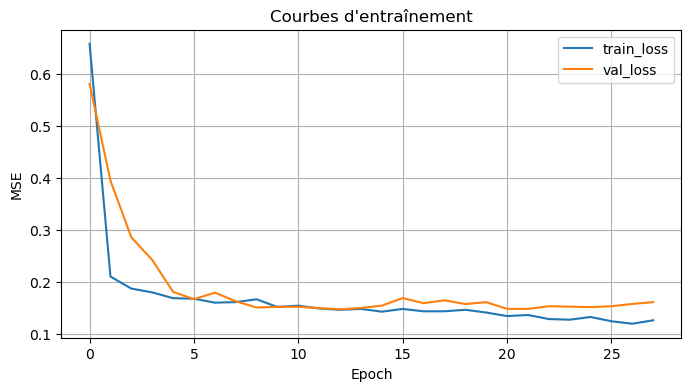

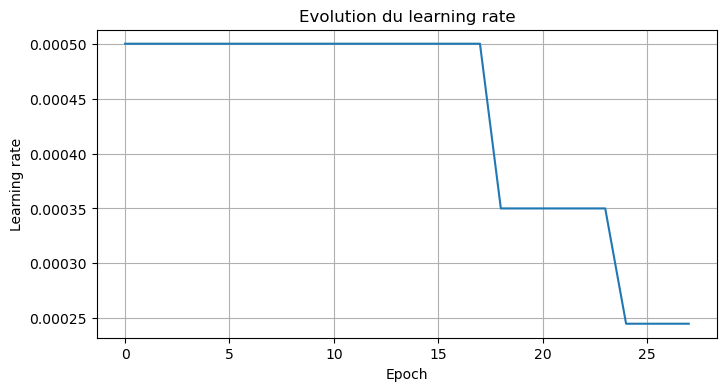

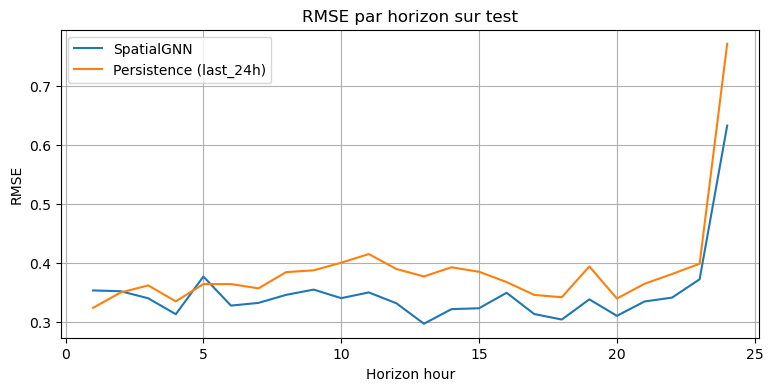

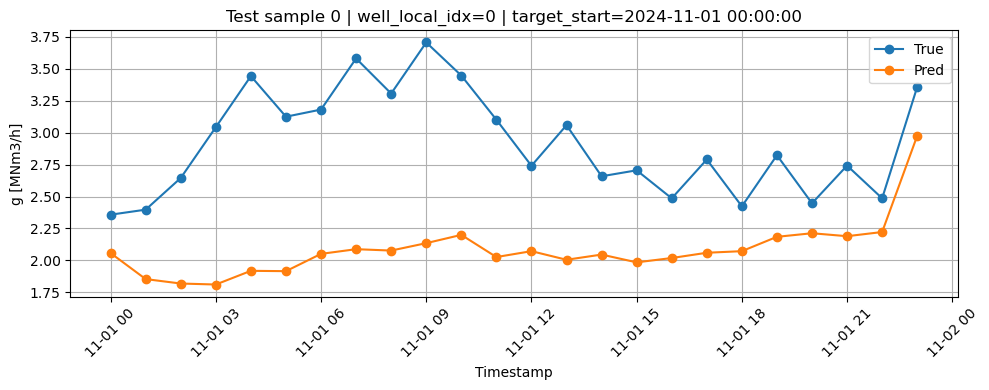

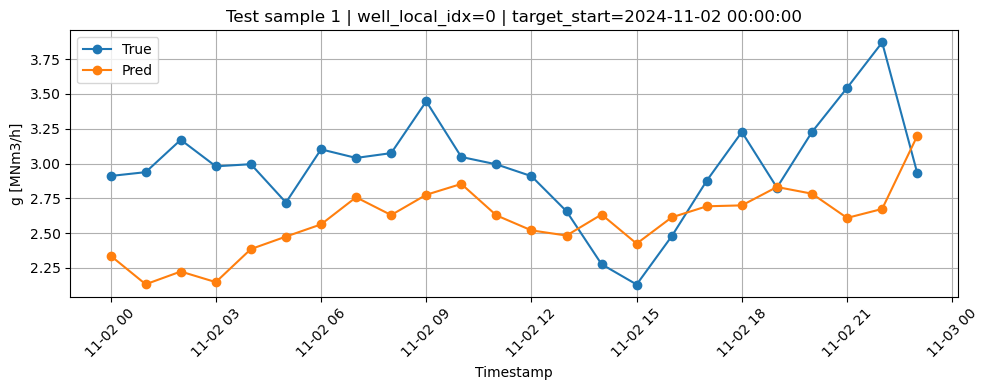

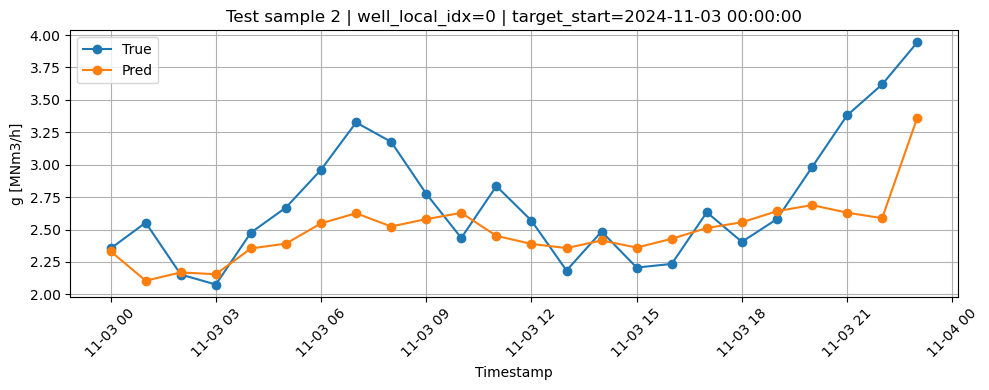

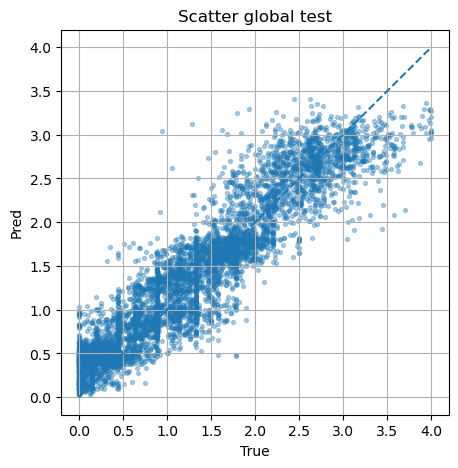

In [134]:
# ============================================================
# Cellule 22 - Plots détaillés
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Courbes d'entraînement")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["lr"])
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Evolution du learning rate")
plt.grid(True)
plt.show()

test_horizon_df = per_horizon_metrics(test_out["trues_real"], test_out["preds_real"])
pers_test_horizon_df = per_horizon_metrics(pers_test_true, pers_test_pred)

plt.figure(figsize=(9, 4))
plt.plot(test_horizon_df["h"], test_horizon_df["RMSE"], label="SpatialGNN")
plt.plot(pers_test_horizon_df["h"], pers_test_horizon_df["RMSE"], label=f"Persistence ({CONFIG['PERSISTENCE_MODE']})")
plt.xlabel("Horizon hour")
plt.ylabel("RMSE")
plt.title("RMSE par horizon sur test")
plt.legend()
plt.grid(True)
plt.show()

num_plot_samples = min(CONFIG["NUM_PLOT_SAMPLES"], len(test_out["metas"]))
well_local_idx = CONFIG["PLOT_WELL_LOCAL_INDEX"]

for k in range(num_plot_samples):
    meta = test_out["metas"][k]
    pred = test_out["preds_real"][k, well_local_idx]
    true = test_out["trues_real"][k, well_local_idx]

    target_idx = np.arange(meta["target_start_idx"], meta["target_end_idx"] + 1)
    target_ts = ts_g[target_idx]

    plt.figure(figsize=(10, 4))
    plt.plot(target_ts, true, marker="o", label="True")
    plt.plot(target_ts, pred, marker="o", label="Pred")
    plt.xlabel("Timestamp")
    plt.ylabel("g [MNm3/h]")
    plt.title(
        f"Test sample {k} | well_local_idx={well_local_idx} | "
        f"target_start={ts_g[meta['target_start_idx']]}"
    )
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(test_out["trues_real"].reshape(-1), test_out["preds_real"].reshape(-1), s=8, alpha=0.35)
mn = min(test_out["trues_real"].min(), test_out["preds_real"].min())
mx = max(test_out["trues_real"].max(), test_out["preds_real"].max())
plt.plot([mn, mx], [mn, mx], "--")
plt.xlabel("True")
plt.ylabel("Pred")
plt.title("Scatter global test")
plt.grid(True)
plt.show()

pred_3d shape raw : (61, 4, 24)
true_3d shape raw : (61, 4, 24)
pred_hw shape     : (61, 24, 4)
true_hw shape     : (61, 24, 4)
Premiers target_start_idx : [7320 7344 7368 7392 7416 7440 7464 7488 7512 7536]
Premiers target_end_idx   : [7343 7367 7391 7415 7439 7463 7487 7511 7535 7559]
pred_series shape : (1464, 4)
true_series shape : (1464, 4)

=== TEST reconstruit complet | totaux agrégés ===
MAE total agrégé        : 0.675635
RMSE total agrégé       : 0.852281
Mean(|true total|)      : 5.216006
MAE / Mean(|true|)      : 12.953104%
Std(true total)         : 1.196503
Std(pred total)         : 0.883889

=== Fenêtre affichée 72h | totaux agrégés ===
MAE total agrégé 72h    : 0.676125
RMSE total agrégé 72h   : 0.842728
Mean(|true total|) 72h  : 5.393304
MAE / Mean(|true|) 72h  : 12.536384%
Std(true total) 72h     : 1.087450
Std(pred total) 72h     : 0.764037


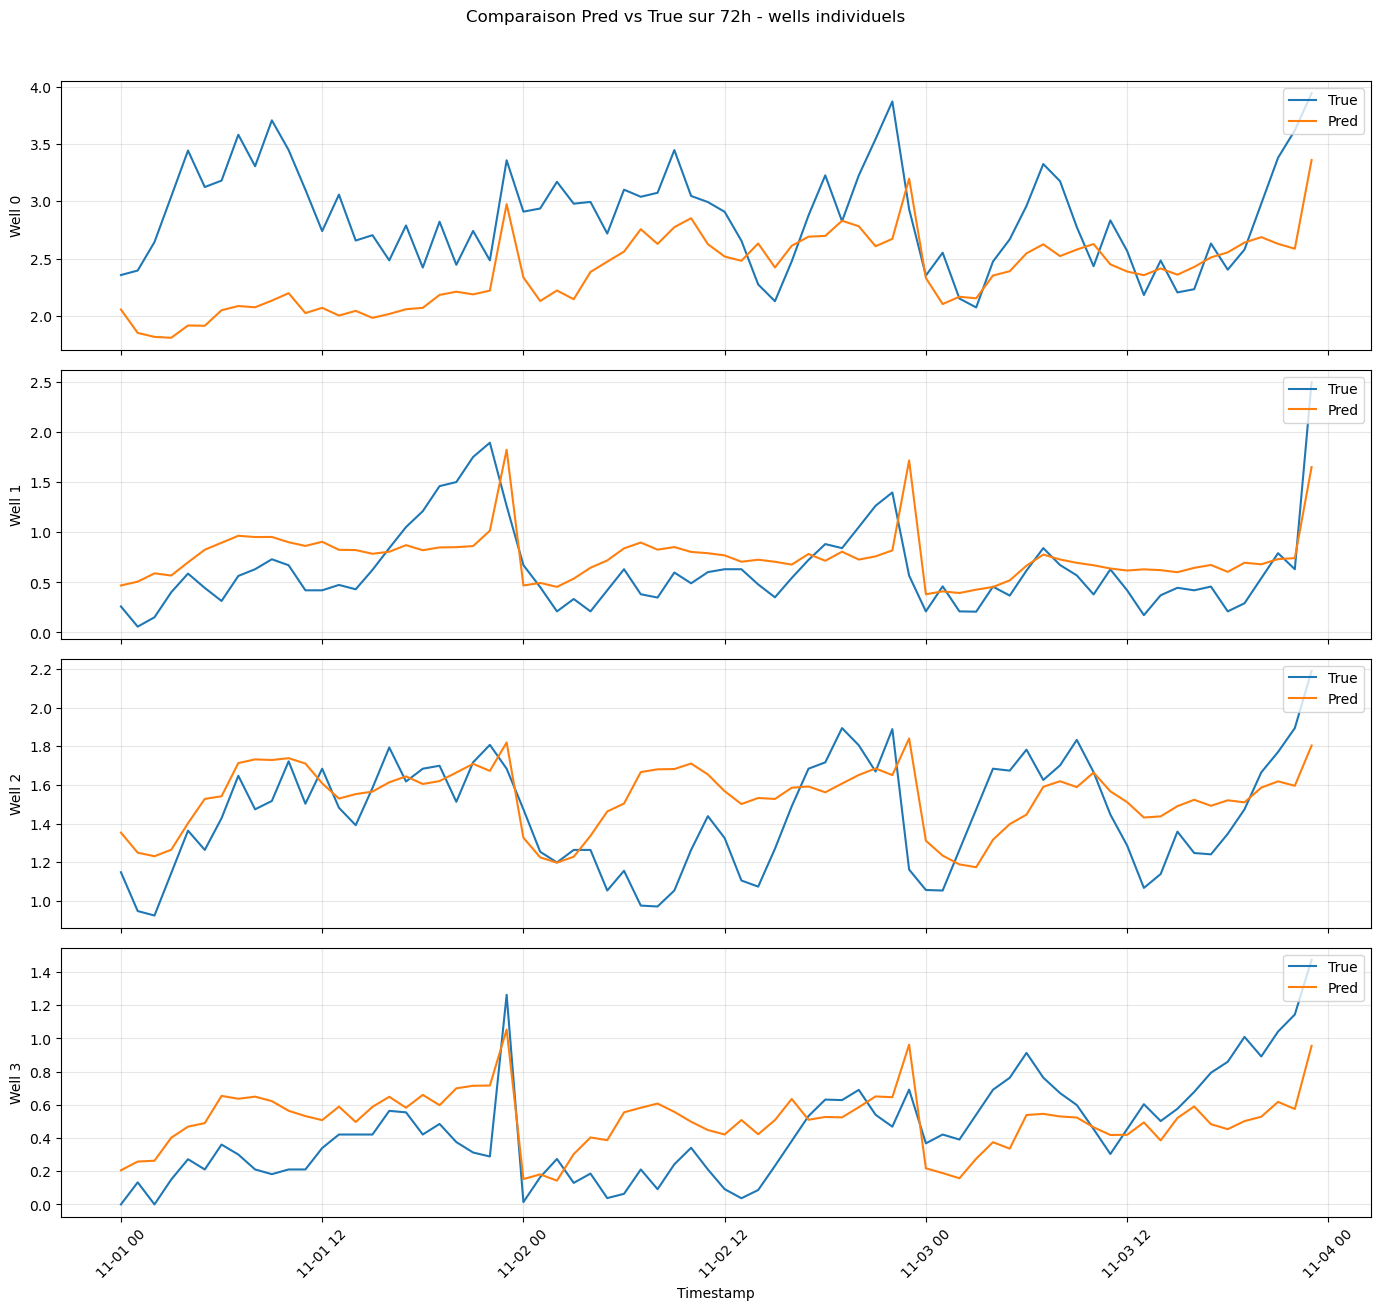

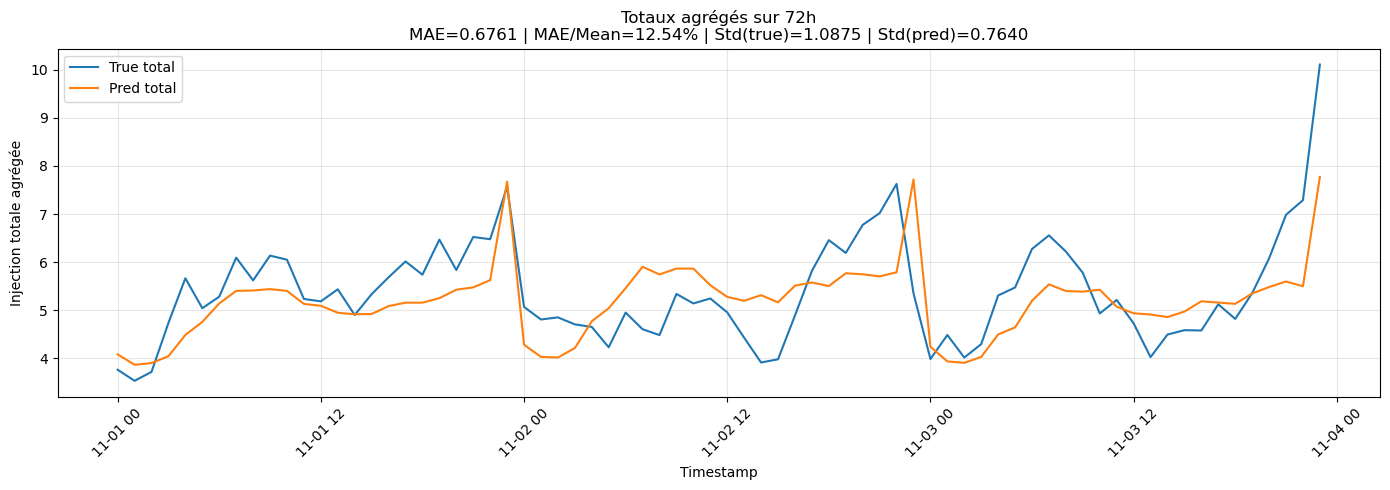

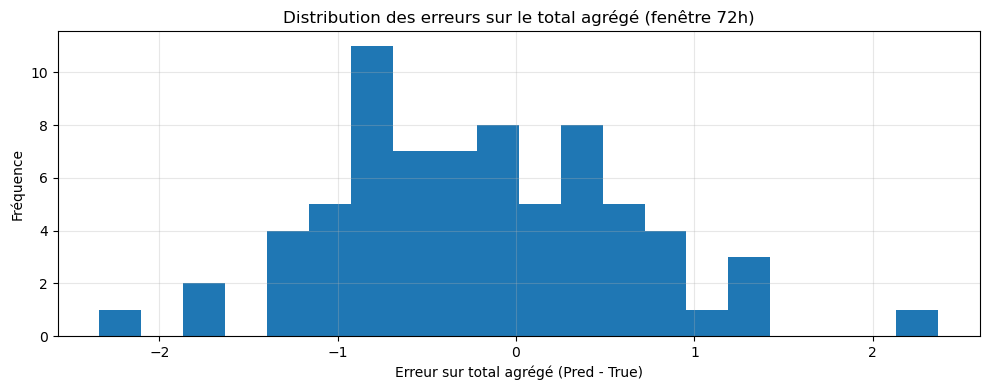

In [135]:
# ============================================================
# Plot 72h sur TEST : wells + total agrégé
# avec MAE/Mean et std sur les totaux agrégés
#
# Cette cellule utilise directement :
#   - test_out["preds_real"]
#   - test_out["trues_real"]
#   - test_out["metas"]
#
# Elle reconstruit une série horaire test en moyennant les
# chevauchements des fenêtres (stride=6h, horizon=24h).
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

assert "test_out" in globals(), "test_out introuvable. Exécute d'abord la cellule d'inférence."
assert "CONFIG" in globals(), "CONFIG introuvable."
assert "ts_g" in globals(), "ts_g introuvable."

pred_3d = np.asarray(test_out["preds_real"])   # (N, 4, 24)
true_3d = np.asarray(test_out["trues_real"])   # (N, 4, 24)
metas   = test_out["metas"]

print("pred_3d shape raw :", pred_3d.shape)
print("true_3d shape raw :", true_3d.shape)

# ------------------------------------------------------------
# On veut travailler en (N, H, W)
# notebook = (N, W, H), donc on transpose
# ------------------------------------------------------------
assert pred_3d.ndim == 3 and true_3d.ndim == 3, "Shapes inattendues"
assert pred_3d.shape == true_3d.shape, "pred/true incompatibles"

N, W, H = pred_3d.shape
assert W == len(CONFIG["WELL_IDX"]), "Nb de wells incohérent"
assert H == CONFIG["HORIZON_HOURS"], "Horizon incohérent"

pred_hw = np.transpose(pred_3d, (0, 2, 1))   # (N, H, W)
true_hw = np.transpose(true_3d, (0, 2, 1))   # (N, H, W)

print("pred_hw shape     :", pred_hw.shape)
print("true_hw shape     :", true_hw.shape)

# ------------------------------------------------------------
# Start indices des targets
# ------------------------------------------------------------
start_idx = np.array([m["target_start_idx"] for m in metas], dtype=int)
end_idx   = np.array([m["target_end_idx"] for m in metas], dtype=int)

print("Premiers target_start_idx :", start_idx[:10])
print("Premiers target_end_idx   :", end_idx[:10])

# ------------------------------------------------------------
# Reconstruction série horaire test avec moyenne sur
# les zones de chevauchement
# ------------------------------------------------------------
T_rec = end_idx.max() + 1
pred_sum = np.zeros((T_rec, W), dtype=float)
true_sum = np.zeros((T_rec, W), dtype=float)
count    = np.zeros((T_rec, 1), dtype=float)

for i in range(N):
    s = start_idx[i]
    e = end_idx[i] + 1
    pred_sum[s:e] += pred_hw[i]
    true_sum[s:e] += true_hw[i]
    count[s:e] += 1.0

valid_mask = count.squeeze() > 0

pred_series = pred_sum[valid_mask] / count[valid_mask]
true_series = true_sum[valid_mask] / count[valid_mask]
ts_series   = ts_g[np.where(valid_mask)[0]]

print("pred_series shape :", pred_series.shape)
print("true_series shape :", true_series.shape)

# ------------------------------------------------------------
# Totaux agrégés
# ------------------------------------------------------------
pred_total = pred_series.sum(axis=1)
true_total = true_series.sum(axis=1)

# métriques globales sur toute la série test reconstruite
mae_total = mean_absolute_error(true_total, pred_total)
rmse_total = np.sqrt(mean_squared_error(true_total, pred_total))
mean_abs_true_total = np.mean(np.abs(true_total))
mae_over_mean = mae_total / (mean_abs_true_total + 1e-12)

std_true_total = np.std(true_total)
std_pred_total = np.std(pred_total)

print("\n=== TEST reconstruit complet | totaux agrégés ===")
print(f"MAE total agrégé        : {mae_total:.6f}")
print(f"RMSE total agrégé       : {rmse_total:.6f}")
print(f"Mean(|true total|)      : {mean_abs_true_total:.6f}")
print(f"MAE / Mean(|true|)      : {mae_over_mean:.6%}")
print(f"Std(true total)         : {std_true_total:.6f}")
print(f"Std(pred total)         : {std_pred_total:.6f}")

# ------------------------------------------------------------
# Choix de la fenêtre 72h à afficher
# plot_start_pos = position dans la série reconstruite
# ------------------------------------------------------------
PLOT_HOURS = 72
plot_start_pos = 0
plot_end_pos = plot_start_pos + PLOT_HOURS

assert len(pred_series) >= PLOT_HOURS, (
    f"Pas assez de points pour afficher {PLOT_HOURS}h "
    f"(len={len(pred_series)})"
)

pred_plot = pred_series[plot_start_pos:plot_end_pos]   # (72, W)
true_plot = true_series[plot_start_pos:plot_end_pos]   # (72, W)
ts_plot   = ts_series[plot_start_pos:plot_end_pos]

pred_total_plot = pred_plot.sum(axis=1)
true_total_plot = true_plot.sum(axis=1)

# métriques sur la fenêtre 72h affichée
mae_total_72 = mean_absolute_error(true_total_plot, pred_total_plot)
rmse_total_72 = np.sqrt(mean_squared_error(true_total_plot, pred_total_plot))
mean_abs_true_total_72 = np.mean(np.abs(true_total_plot))
mae_over_mean_72 = mae_total_72 / (mean_abs_true_total_72 + 1e-12)

std_true_total_72 = np.std(true_total_plot)
std_pred_total_72 = np.std(pred_total_plot)

print("\n=== Fenêtre affichée 72h | totaux agrégés ===")
print(f"MAE total agrégé 72h    : {mae_total_72:.6f}")
print(f"RMSE total agrégé 72h   : {rmse_total_72:.6f}")
print(f"Mean(|true total|) 72h  : {mean_abs_true_total_72:.6f}")
print(f"MAE / Mean(|true|) 72h  : {mae_over_mean_72:.6%}")
print(f"Std(true total) 72h     : {std_true_total_72:.6f}")
print(f"Std(pred total) 72h     : {std_pred_total_72:.6f}")

# ------------------------------------------------------------
# Plot wells individuels
# ------------------------------------------------------------
fig, axes = plt.subplots(W, 1, figsize=(14, 3.2 * W), sharex=True)

if W == 1:
    axes = [axes]

for w in range(W):
    axes[w].plot(ts_plot, true_plot[:, w], label="True")
    axes[w].plot(ts_plot, pred_plot[:, w], label="Pred")
    axes[w].set_ylabel(f"Well {w}")
    axes[w].grid(True, alpha=0.3)
    axes[w].legend(loc="upper right")

axes[-1].set_xlabel("Timestamp")
fig.suptitle("Comparaison Pred vs True sur 72h - wells individuels", y=1.02)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot total agrégé
# ------------------------------------------------------------
plt.figure(figsize=(14, 5))
plt.plot(ts_plot, true_total_plot, label="True total")
plt.plot(ts_plot, pred_total_plot, label="Pred total")
plt.grid(True, alpha=0.3)
plt.xlabel("Timestamp")
plt.ylabel("Injection totale agrégée")
plt.title(
    "Totaux agrégés sur 72h\n"
    f"MAE={mae_total_72:.4f} | MAE/Mean={mae_over_mean_72:.2%} | "
    f"Std(true)={std_true_total_72:.4f} | Std(pred)={std_pred_total_72:.4f}"
)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Histogramme des erreurs agrégées sur la fenêtre 72h
# ------------------------------------------------------------
err_total_plot = pred_total_plot - true_total_plot

plt.figure(figsize=(10, 4))
plt.hist(err_total_plot, bins=20)
plt.grid(True, alpha=0.3)
plt.xlabel("Erreur sur total agrégé (Pred - True)")
plt.ylabel("Fréquence")
plt.title("Distribution des erreurs sur le total agrégé (fenêtre 72h)")
plt.tight_layout()
plt.show()